# Module 3: ML Models

**Muc tieu:** Train 3 mo hinh ML:
- **3.1** K-Means Clustering — phan cum phim
- **3.2** Naive Bayes — phan loai the loai tu poster
- **3.3** Association Rules (Apriori) — luat ket hop the loai

**Input:**
- `models/combined_features.npy`
- `models/cnn_features.npy`
- `models/movie_ids.npy`
- `data/processed/movies_valid.csv`

**Output:**
- `models/kmeans.pkl`, `models/cluster_labels.npy`
- `models/nb_model.pkl`, `models/mlb_encoder.pkl`
- `models/rules.csv`
- `data/processed/movies_valid.csv` (cap nhat them cot cluster_id, pca_x, pca_y)

In [1]:
# !pip install scikit-learn mlxtend joblib numpy pandas matplotlib

In [2]:
import numpy as np
import pandas as pd
import json
import joblib
import matplotlib.pyplot as plt
import os

# Load du lieu dau vao
combined = np.load("../models/combined_features.npy")
cnn      = np.load("../models/cnn_features.npy")
movie_ids = np.load("../models/movie_ids.npy")
df = pd.read_csv("../data/processed/movies_valid.csv")

print(f"combined_features: {combined.shape}")
print(f"cnn_features:      {cnn.shape}")
print(f"movie_ids:         {movie_ids.shape}")
print(f"df (movies_valid): {df.shape}")

assert combined.shape[0] == cnn.shape[0] == len(movie_ids) == len(df), \
    "So luong phim khong khop giua cac file!"
print("Kiem tra so luong: PASS")

combined_features: (4768, 2548)
cnn_features:      (4768, 2048)
movie_ids:         (4768,)
df (movies_valid): (4768, 9)
Kiem tra so luong: PASS


---
## 3.1 K-Means Clustering

### 3.1.1 Elbow Curve — chon K toi uu

Dang tinh Elbow Curve...
  K= 5 | Inertia: 100161
  K=10 | Inertia: 97724
  K=15 | Inertia: 96167
  K=20 | Inertia: 94640
  K=25 | Inertia: 94676
  K=30 | Inertia: 94584
  K=35 | Inertia: 93240
  K=40 | Inertia: 93000


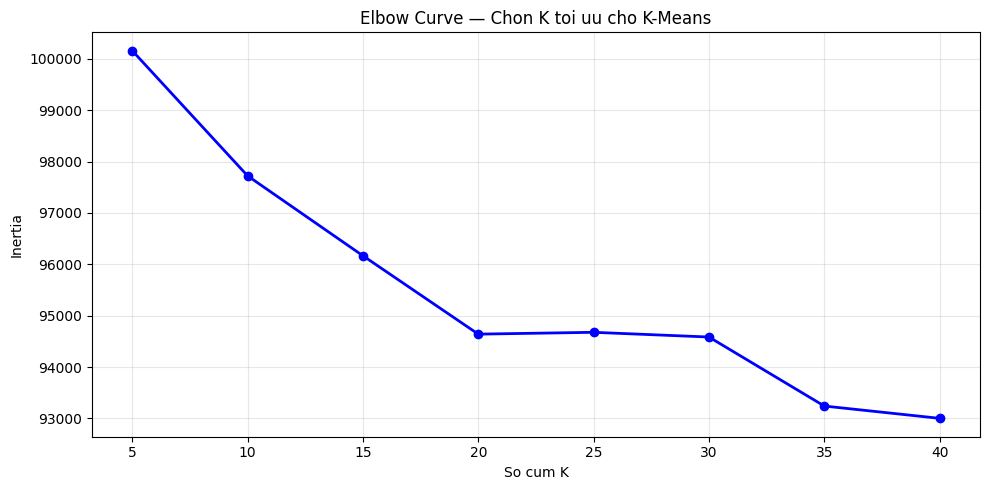

Da luu elbow_curve.png


In [3]:
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Dung MiniBatchKMeans de tinh nhanh Elbow Curve
K_range = range(5, 41, 5)
inertias = []

print("Dang tinh Elbow Curve...")
for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=1024)
    km.fit(combined)
    inertias.append(km.inertia_)
    print(f"  K={k:2d} | Inertia: {km.inertia_:.0f}")

# Ve Elbow Curve
plt.figure(figsize=(10, 5))
plt.plot(list(K_range), inertias, 'bo-', linewidth=2)
plt.xlabel('So cum K')
plt.ylabel('Inertia')
plt.title('Elbow Curve — Chon K toi uu cho K-Means')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../models/elbow_curve.png", dpi=100)
plt.show()
print("Da luu elbow_curve.png")

In [4]:
# Chon K dua tren Elbow Curve o tren
# Mac dinh K=20 theo plan, dieu chinh neu can
K_OPTIMAL = 20
print(f"K toi uu duoc chon: {K_OPTIMAL}")
print("(Xem bieu do Elbow Curve o tren de dieu chinh neu can)")

K toi uu duoc chon: 20
(Xem bieu do Elbow Curve o tren de dieu chinh neu can)


### 3.1.2 Train KMeans voi K toi uu

In [5]:
print(f"Dang train KMeans(k={K_OPTIMAL})...")
kmeans = KMeans(
    n_clusters=K_OPTIMAL,
    random_state=42,
    n_init=10,
    max_iter=300
)
cluster_labels = kmeans.fit_predict(combined)

print(f"Train xong!")
print(f"Inertia: {kmeans.inertia_:.0f}")

# Thong ke so phim moi cum
unique, counts = np.unique(cluster_labels, return_counts=True)
print(f"\nSo phim moi cum:")
for cid, cnt in zip(unique, counts):
    print(f"  Cum {cid:2d}: {cnt} phim")

Dang train KMeans(k=20)...
Train xong!
Inertia: 93567

So phim moi cum:
  Cum  0: 133 phim
  Cum  1: 273 phim
  Cum  2: 250 phim
  Cum  3: 207 phim
  Cum  4: 268 phim
  Cum  5: 289 phim
  Cum  6: 191 phim
  Cum  7: 256 phim
  Cum  8: 336 phim
  Cum  9: 236 phim
  Cum 10: 241 phim
  Cum 11: 346 phim
  Cum 12: 335 phim
  Cum 13: 174 phim
  Cum 14: 151 phim
  Cum 15: 254 phim
  Cum 16: 178 phim
  Cum 17: 120 phim
  Cum 18: 235 phim
  Cum 19: 295 phim


### 3.1.3 Danh gia Silhouette Score & Davies-Bouldin Index

In [6]:
# Dung subset 2000 mau de tinh nhanh (silhouette toan bo rat cham)
sample_size = min(2000, len(combined))
np.random.seed(42)
sample_idx = np.random.choice(len(combined), sample_size, replace=False)

sil_score = silhouette_score(combined[sample_idx], cluster_labels[sample_idx])
db_score  = davies_bouldin_score(combined[sample_idx], cluster_labels[sample_idx])

print(f"Silhouette Score:      {sil_score:.4f}  (tot >= 0.3, cang cao cang tot)")
print(f"Davies-Bouldin Index:  {db_score:.4f}  (cang thap cang tot)")

if sil_score >= 0.3:
    print("Silhouette >= 0.3: PASS")
else:
    print(f"Silhouette < 0.3: co the thu dieu chinh K")

Silhouette Score:      -0.0043  (tot >= 0.3, cang cao cang tot)
Davies-Bouldin Index:  5.0640  (cang thap cang tot)
Silhouette < 0.3: co the thu dieu chinh K


### 3.1.4 Precompute PCA 2D

Dang tinh PCA 2D...
PCA explained variance: 6.7%


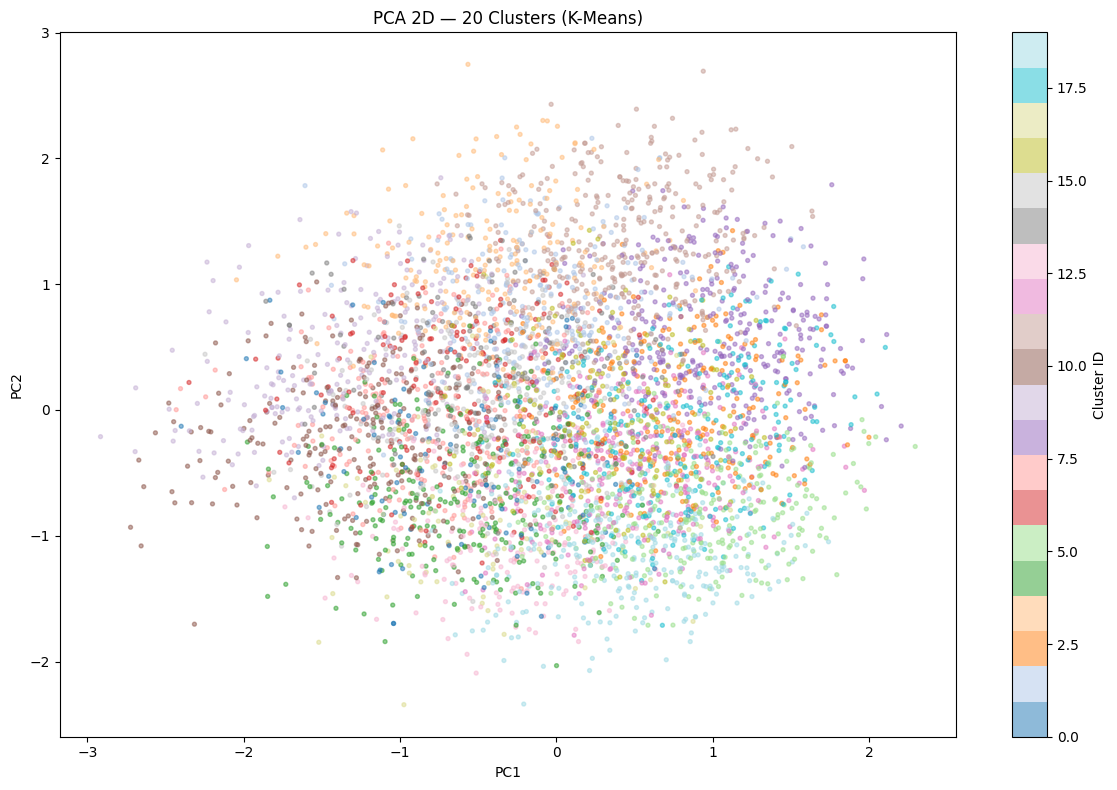

Da luu pca_clusters.png


In [7]:
from sklearn.decomposition import PCA

print("Dang tinh PCA 2D...")
pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(combined)

pca_x = pca_coords[:, 0]
pca_y = pca_coords[:, 1]

print(f"PCA explained variance: {pca.explained_variance_ratio_.sum()*100:.1f}%")

# Visualize
plt.figure(figsize=(12, 8))
scatter = plt.scatter(pca_x, pca_y, c=cluster_labels, cmap='tab20', alpha=0.5, s=8)
plt.colorbar(scatter, label='Cluster ID')
plt.title(f'PCA 2D — {K_OPTIMAL} Clusters (K-Means)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.tight_layout()
plt.savefig("../models/pca_clusters.png", dpi=100)
plt.show()
print("Da luu pca_clusters.png")

### 3.1.5 & 3.1.6 Luu cluster_id, pca_x, pca_y vao CSV + luu model

In [8]:
# Cap nhat df voi cluster_id, pca_x, pca_y
df['cluster_id'] = cluster_labels
df['pca_x'] = pca_x
df['pca_y'] = pca_y

# Luu lai movies_valid.csv
df.to_csv("../data/processed/movies_valid.csv", index=False)
print(f"Da cap nhat movies_valid.csv voi cluster_id, pca_x, pca_y")

# Luu model va labels
joblib.dump(kmeans, "../models/kmeans.pkl")
np.save("../models/cluster_labels.npy", cluster_labels)
print("Da luu kmeans.pkl va cluster_labels.npy")

Da cap nhat movies_valid.csv voi cluster_id, pca_x, pca_y
Da luu kmeans.pkl va cluster_labels.npy


---
## 3.2 Naive Bayes — Multi-label Genre Classification

### 3.2.1 & 3.2.2 Tao multi-label binary matrix, loc the loai >= 100 phim

In [9]:
from sklearn.preprocessing import MultiLabelBinarizer
from collections import Counter

# Parse genres
genres_lists = df['genres'].apply(json.loads).tolist()

# Dem so phim moi the loai
all_genres_flat = [g for gl in genres_lists for g in gl]
genre_counts = Counter(all_genres_flat)

print("So phim moi the loai:")
for genre, count in sorted(genre_counts.items(), key=lambda x: -x[1]):
    flag = "OK" if count >= 100 else "< 100, bo qua"
    print(f"  {genre:<25} {count:4d}  {flag}")

# Giu lai the loai co >= 100 phim
valid_genres = [g for g, c in genre_counts.items() if c >= 100]
print(f"\nSo the loai hop le (>= 100 phim): {len(valid_genres)}")
print(f"Cac the loai: {sorted(valid_genres)}")

So phim moi the loai:
  Drama                     2292  OK
  Comedy                    1722  OK
  Thriller                  1278  OK
  Action                    1153  OK
  Romance                    895  OK
  Adventure                  789  OK
  Crime                      697  OK
  Science Fiction            534  OK
  Horror                     522  OK
  Family                     513  OK
  Fantasy                    423  OK
  Mystery                    348  OK
  Animation                  233  OK
  History                    197  OK
  Music                      183  OK
  War                        144  OK
  Documentary                105  OK
  Western                     82  < 100, bo qua
  Foreign                     36  < 100, bo qua
  TV Movie                     8  < 100, bo qua

So the loai hop le (>= 100 phim): 17
Cac the loai: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 

In [10]:
# Loc genres_lists chi giu the loai hop le
genres_filtered = [[g for g in gl if g in valid_genres] for gl in genres_lists]

# MultiLabelBinarizer
mlb = MultiLabelBinarizer(classes=sorted(valid_genres))
Y = mlb.fit_transform(genres_filtered)

print(f"Label matrix shape: {Y.shape}")  # (N, n_genres)
print(f"Classes: {mlb.classes_.tolist()}")

Label matrix shape: (4768, 17)
Classes: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'Thriller', 'War']


### 3.2.3 Train/Test Split 80/20

In [11]:
from sklearn.model_selection import train_test_split

# Dung CNN features lam input cho Naive Bayes
X_train, X_test, Y_train, Y_test = train_test_split(
    cnn, Y, test_size=0.2, random_state=42
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Y_train: {Y_train.shape}")
print(f"Y_test:  {Y_test.shape}")

X_train: (3814, 2048)
X_test:  (954, 2048)
Y_train: (3814, 17)
Y_test:  (954, 17)


### 3.2.4 Train MultiOutputClassifier(GaussianNB)

In [12]:
from sklearn.naive_bayes import GaussianNB
from sklearn.multioutput import MultiOutputClassifier

print("Dang train Naive Bayes...")
nb_model = MultiOutputClassifier(GaussianNB(), n_jobs=-1)
nb_model.fit(X_train, Y_train)
print("Train xong!")

Dang train Naive Bayes...
Train xong!


### 3.2.5 Danh gia: Hamming Loss, F1, Precision, Recall

In [13]:
from sklearn.metrics import (
    hamming_loss, f1_score, precision_score, recall_score,
    classification_report
)

Y_pred = nb_model.predict(X_test)

hl    = hamming_loss(Y_test, Y_pred)
f1_mi = f1_score(Y_test, Y_pred, average='micro', zero_division=0)
f1_ma = f1_score(Y_test, Y_pred, average='macro', zero_division=0)
prec  = precision_score(Y_test, Y_pred, average='micro', zero_division=0)
rec   = recall_score(Y_test, Y_pred, average='micro', zero_division=0)

print("=" * 50)
print("KET QUA DANH GIA NAIVE BAYES")
print("=" * 50)
print(f"Hamming Loss:      {hl:.4f}  (cang thap cang tot)")
print(f"F1 (micro):        {f1_mi:.4f}")
print(f"F1 (macro):        {f1_ma:.4f}")
print(f"Precision (micro): {prec:.4f}")
print(f"Recall (micro):    {rec:.4f}")

# Exact match accuracy (phai du het cac nhan)
exact_match = np.mean(np.all(Y_pred == Y_test, axis=1))
print(f"Exact Match Acc:   {exact_match:.4f}")

# Per-label accuracy
per_label_acc = np.mean(Y_pred == Y_test, axis=0)
print(f"\nPer-label accuracy:")
for label, acc in zip(mlb.classes_, per_label_acc):
    print(f"  {label:<25} {acc:.3f}")

KET QUA DANH GIA NAIVE BAYES
Hamming Loss:      0.2498  (cang thap cang tot)
F1 (micro):        0.4563
F1 (macro):        0.3876
Precision (micro): 0.3412
Recall (micro):    0.6888
Exact Match Acc:   0.0105

Per-label accuracy:
  Action                    0.729
  Adventure                 0.719
  Animation                 0.910
  Comedy                    0.738
  Crime                     0.657
  Documentary               0.863
  Drama                     0.634
  Family                    0.834
  Fantasy                   0.741
  History                   0.724
  Horror                    0.780
  Music                     0.756
  Mystery                   0.751
  Romance                   0.661
  Science Fiction           0.749
  Thriller                  0.702
  War                       0.805


### 3.2.6 Luu nb_model.pkl & mlb_encoder.pkl

In [14]:
joblib.dump(nb_model, "../models/nb_model.pkl")
joblib.dump(mlb, "../models/mlb_encoder.pkl")
print("Da luu nb_model.pkl va mlb_encoder.pkl")

# Test nhanh
nb_loaded = joblib.load("../models/nb_model.pkl")
mlb_loaded = joblib.load("../models/mlb_encoder.pkl")
pred_test = nb_loaded.predict(cnn[:5])
genres_pred = mlb_loaded.inverse_transform(pred_test)
print(f"\nTest prediction cho 5 phim dau:")
for i, (gp, title) in enumerate(zip(genres_pred, df['title'].head(5))):
    gt = json.loads(df.iloc[i]['genres'])
    print(f"  {title[:30]:<30} | Du doan: {list(gp)} | Thuc te: {gt}")

Da luu nb_model.pkl va mlb_encoder.pkl

Test prediction cho 5 phim dau:
  Avatar                         | Du doan: ['Drama', 'Fantasy', 'History', 'Horror', 'Mystery', 'Science Fiction', 'Thriller', 'War'] | Thuc te: ['Action', 'Adventure', 'Fantasy', 'Science Fiction']
  Pirates of the Caribbean: At W | Du doan: ['Action', 'Adventure', 'Fantasy', 'Horror', 'Science Fiction'] | Thuc te: ['Adventure', 'Fantasy', 'Action']
  Spectre                        | Du doan: ['Comedy', 'Crime', 'Romance'] | Thuc te: ['Action', 'Adventure', 'Crime']
  The Dark Knight Rises          | Du doan: ['Action', 'Adventure', 'Fantasy', 'Horror', 'Science Fiction', 'Thriller', 'War'] | Thuc te: ['Action', 'Crime', 'Drama', 'Thriller']
  John Carter                    | Du doan: ['Action', 'Adventure', 'Family', 'Fantasy', 'Science Fiction'] | Thuc te: ['Action', 'Adventure', 'Science Fiction']


---
## 3.3 Association Rules (Apriori)

### 3.3.1 Tao transaction matrix

In [15]:
# Dung tat ca the loai (khong gioi han >= 100)
all_genre_names = sorted(set(all_genres_flat))

# Tao transaction matrix (0/1)
mlb_apriori = MultiLabelBinarizer(classes=all_genre_names)
transaction_matrix = mlb_apriori.fit_transform(genres_lists)
df_transactions = pd.DataFrame(transaction_matrix, columns=all_genre_names, dtype=bool)

print(f"Transaction matrix shape: {df_transactions.shape}")
print(f"So the loai: {len(all_genre_names)}")
print(f"Cac the loai: {all_genre_names}")

Transaction matrix shape: (4768, 20)
So the loai: 20
Cac the loai: ['Action', 'Adventure', 'Animation', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction', 'TV Movie', 'Thriller', 'War', 'Western']


### 3.3.2 Apriori

In [16]:
from mlxtend.frequent_patterns import apriori, association_rules

print("Dang chay Apriori (min_support=0.05)...")
frequent_itemsets = apriori(
    df_transactions,
    min_support=0.05,
    use_colnames=True,
    max_len=3
)

print(f"So frequent itemsets: {len(frequent_itemsets)}")
print(frequent_itemsets.sort_values('support', ascending=False).head(10))

Dang chay Apriori (min_support=0.05)...
So frequent itemsets: 27
     support                      itemsets
4   0.480705            frozenset({Drama})
2   0.361158           frozenset({Comedy})
11  0.268037         frozenset({Thriller})
0   0.241820           frozenset({Action})
9   0.187710          frozenset({Romance})
1   0.165478        frozenset({Adventure})
3   0.146183            frozenset({Crime})
23  0.126258   frozenset({Drama, Romance})
18  0.120596    frozenset({Drama, Comedy})
24  0.116401  frozenset({Drama, Thriller})


### 3.3.3 & 3.3.4 Sinh luat ket hop, loc lift > 1.0

In [17]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.4
)

# Chi giu luat co lift > 1.0 (co y nghia thong ke)
rules = rules[rules['lift'] > 1.0].copy()

# Sap xep theo confidence giam dan
rules = rules.sort_values(['confidence', 'lift'], ascending=False).reset_index(drop=True)

print(f"So luat ket hop (lift > 1.0): {len(rules)}")
print(f"\nTop 15 luat ket hop:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15).to_string())

assert len(rules) >= 10, f"Chi co {len(rules)} luat, can >= 10. Thu giam min_support."

So luat ket hop (lift > 1.0): 12

Top 15 luat ket hop:
                     antecedents             consequents   support  confidence      lift
0           frozenset({Mystery})   frozenset({Thriller})  0.050755    0.695402  2.594427
1           frozenset({Romance})      frozenset({Drama})  0.126258    0.672626  1.399249
2             frozenset({Crime})   frozenset({Thriller})  0.087248    0.596844  2.226722
3         frozenset({Adventure})     frozenset({Action})  0.097315    0.588086  2.431912
4            frozenset({Family})     frozenset({Comedy})  0.062710    0.582846  1.613827
5            frozenset({Horror})   frozenset({Thriller})  0.061242    0.559387  2.086977
6             frozenset({Crime})      frozenset({Drama})  0.079488    0.543759  1.131170
7           frozenset({Romance})     frozenset({Comedy})  0.101930    0.543017  1.503545
8   frozenset({Science Fiction})     frozenset({Action})  0.057676    0.514981  2.129602
9            frozenset({Action})   frozenset({Thriller}

### 3.3.5 Luu rules.csv

In [18]:
# Chuyen frozenset sang string de luu CSV
rules_export = rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(sorted(x)))

rules_export.to_csv("../models/rules.csv", index=False)
print(f"Da luu {len(rules_export)} luat vao models/rules.csv")
print(rules_export.head(5).to_string())

Da luu 12 luat vao models/rules.csv
  antecedents consequents   support  confidence      lift
0     Mystery    Thriller  0.050755    0.695402  2.594427
1     Romance       Drama  0.126258    0.672626  1.399249
2       Crime    Thriller  0.087248    0.596844  2.226722
3   Adventure      Action  0.097315    0.588086  2.431912
4      Family      Comedy  0.062710    0.582846  1.613827


---
## Test Module 3 (Tong hop)

In [19]:
import joblib, numpy as np, pandas as pd
from sklearn.metrics import silhouette_score

combined   = np.load("../models/combined_features.npy")
cnn        = np.load("../models/cnn_features.npy")
labels     = np.load("../models/cluster_labels.npy")
kmeans_m   = joblib.load("../models/kmeans.pkl")
nb_m       = joblib.load("../models/nb_model.pkl")
mlb_m      = joblib.load("../models/mlb_encoder.pkl")
rules_df   = pd.read_csv("../models/rules.csv")

print("=" * 55)
print("TEST MODULE 3")
print("=" * 55)

# --- K-Means ---
sample_idx = np.random.choice(len(combined), min(1000, len(combined)), replace=False)
sil = silhouette_score(combined[sample_idx], labels[sample_idx])
n_clusters = len(set(labels))
print(f"[K-Means] Silhouette Score: {sil:.3f}  {'PASS' if sil >= 0.3 else 'WARN (< 0.3)'}")
print(f"[K-Means] So cum: {n_clusters}")

# --- Naive Bayes ---
pred = nb_m.predict(cnn[:5])
genres_pred = mlb_m.inverse_transform(pred)
print(f"\n[NB] Prediction cho 5 phim dau:")
for gp in genres_pred:
    print(f"  {list(gp)}")

# --- Association Rules ---
print(f"\n[Rules] So luat: {len(rules_df)}  {'PASS' if len(rules_df) >= 10 else 'FAIL'}")
print(rules_df[['antecedents', 'consequents', 'confidence', 'lift']].head(5).to_string())

print("\nModule 3 hoan thanh! San sang cho Module 4.")

TEST MODULE 3
[K-Means] Silhouette Score: -0.009  WARN (< 0.3)
[K-Means] So cum: 20

[NB] Prediction cho 5 phim dau:
  ['Drama', 'Fantasy', 'History', 'Horror', 'Mystery', 'Science Fiction', 'Thriller', 'War']
  ['Action', 'Adventure', 'Fantasy', 'Horror', 'Science Fiction']
  ['Comedy', 'Crime', 'Romance']
  ['Action', 'Adventure', 'Fantasy', 'Horror', 'Science Fiction', 'Thriller', 'War']
  ['Action', 'Adventure', 'Family', 'Fantasy', 'Science Fiction']

[Rules] So luat: 12  PASS
  antecedents consequents  confidence      lift
0     Mystery    Thriller    0.695402  2.594427
1     Romance       Drama    0.672626  1.399249
2       Crime    Thriller    0.596844  2.226722
3   Adventure      Action    0.588086  2.431912
4      Family      Comedy    0.582846  1.613827

Module 3 hoan thanh! San sang cho Module 4.


In [20]:
# Tong ket cac file da tao
print("=" * 55)
print("FILE OUTPUT MODULE 3")
print("=" * 55)
files = [
    "../models/kmeans.pkl",
    "../models/cluster_labels.npy",
    "../models/nb_model.pkl",
    "../models/mlb_encoder.pkl",
    "../models/rules.csv",
    "../models/elbow_curve.png",
    "../models/pca_clusters.png",
    "../data/processed/movies_valid.csv",
]
for f in files:
    if os.path.exists(f):
        size = os.path.getsize(f) / 1024
        print(f"  [OK] {f:<45} {size:.1f} KB")
    else:
        print(f"  [MISS] {f}")

FILE OUTPUT MODULE 3
  [OK] ../models/kmeans.pkl                          218.4 KB
  [OK] ../models/cluster_labels.npy                  18.8 KB
  [OK] ../models/nb_model.pkl                        554.8 KB
  [OK] ../models/mlb_encoder.pkl                     0.9 KB
  [OK] ../models/rules.csv                           0.9 KB
  [OK] ../models/elbow_curve.png                     31.6 KB
  [OK] ../models/pca_clusters.png                    373.6 KB
  [OK] ../data/processed/movies_valid.csv            2773.7 KB


Dang tinh Elbow Curve de ve bieu do...
  K= 5 | Inertia: 100161
  K=10 | Inertia: 97724
  K=15 | Inertia: 96167
  K=20 | Inertia: 94640
  K=25 | Inertia: 94676
  K=30 | Inertia: 94584
  K=35 | Inertia: 93240
  K=40 | Inertia: 93000


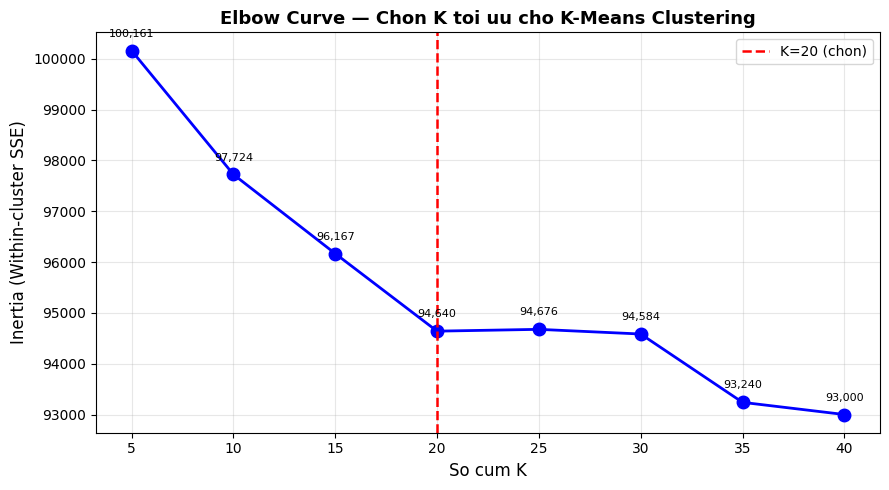

Da luu: ../output\03_kmeans_elbow_curve.png
Dang tinh PCA 2D cho clustering...


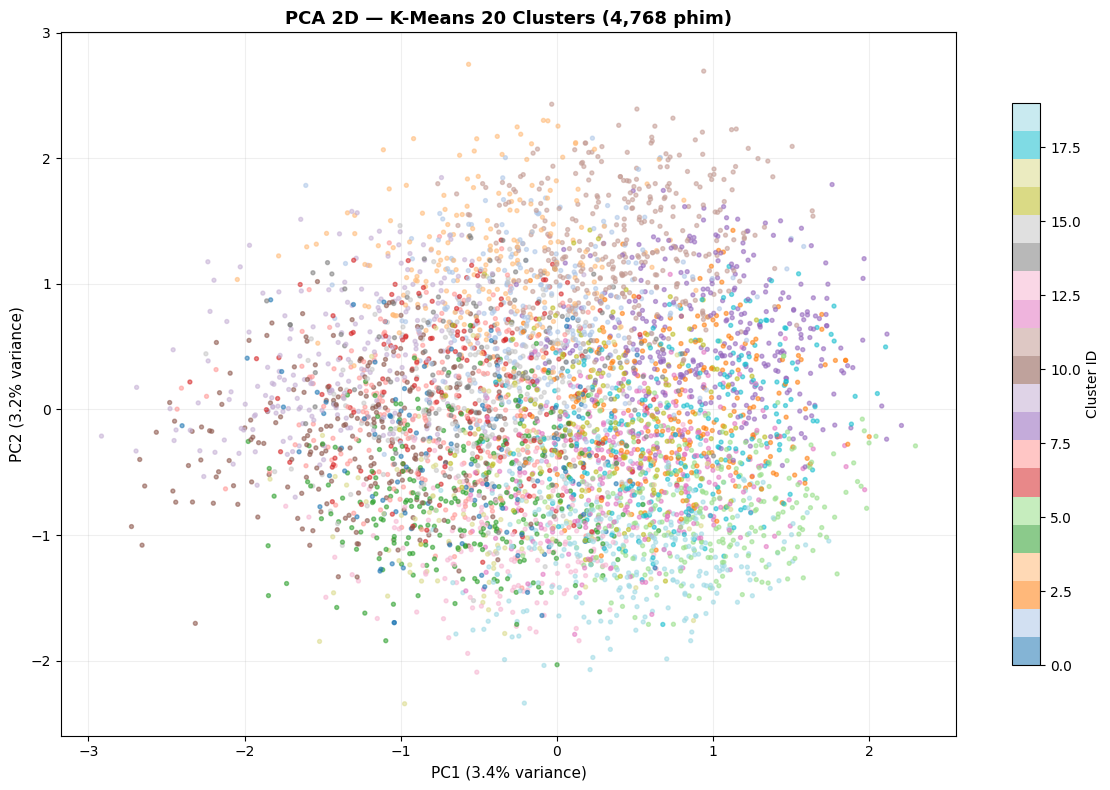

Da luu: ../output\03_kmeans_pca_clusters.png


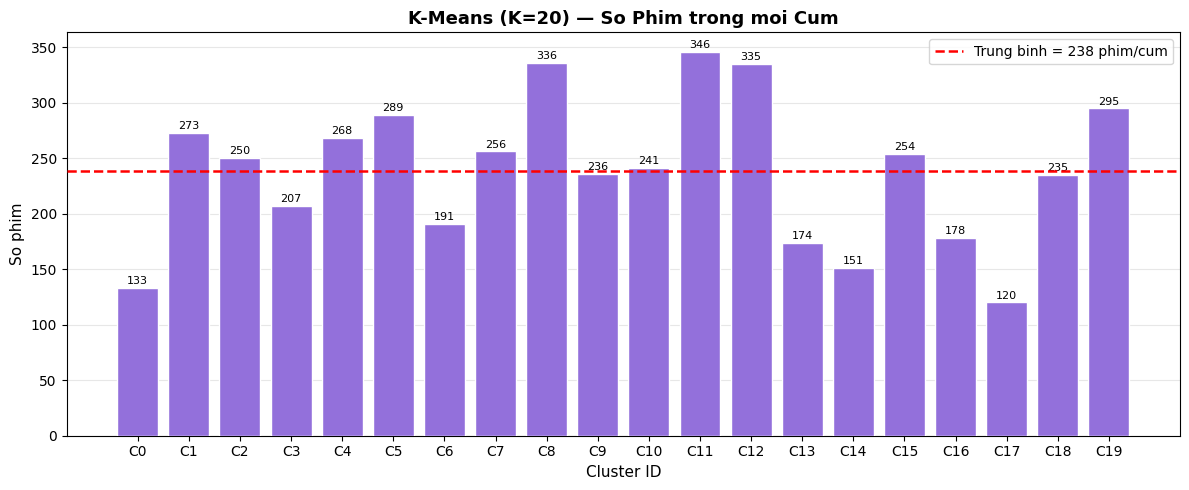

Da luu: ../output\03_kmeans_cluster_sizes.png


C:\Users\ACER\AppData\Local\Temp\ipykernel_11372\4036902247.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nb_labels, rotation=35, ha='right', fontsize=9)


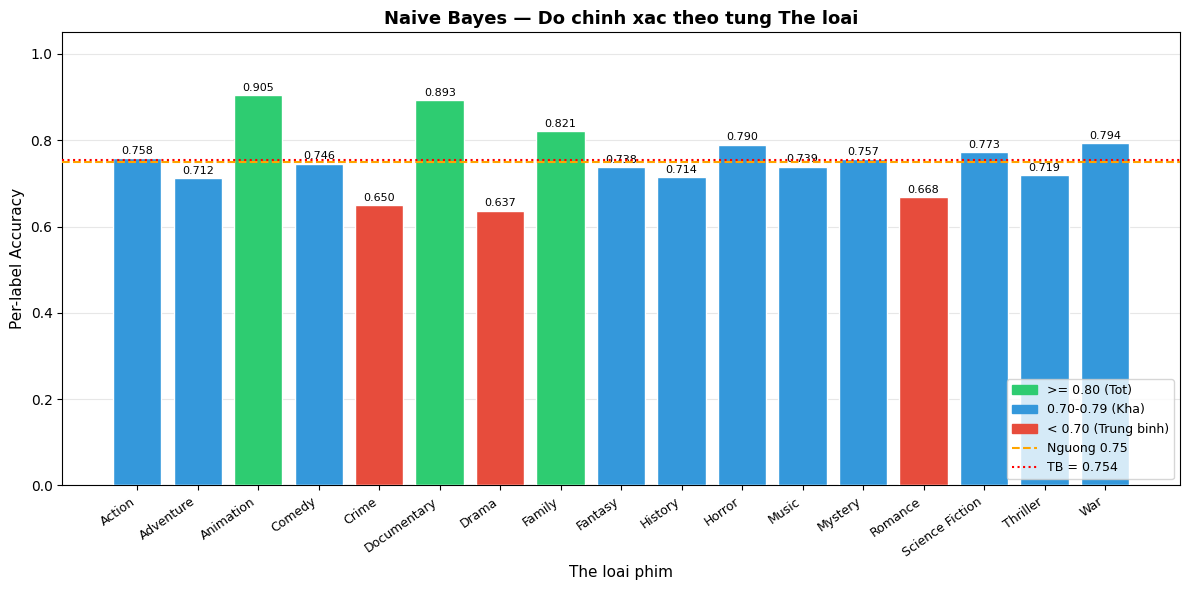

Da luu: ../output\03_nb_per_label_accuracy.png


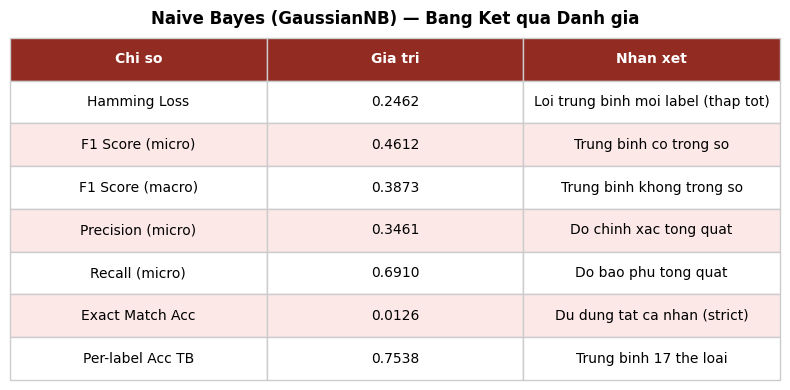

Da luu: ../output\03_nb_metrics_table.png


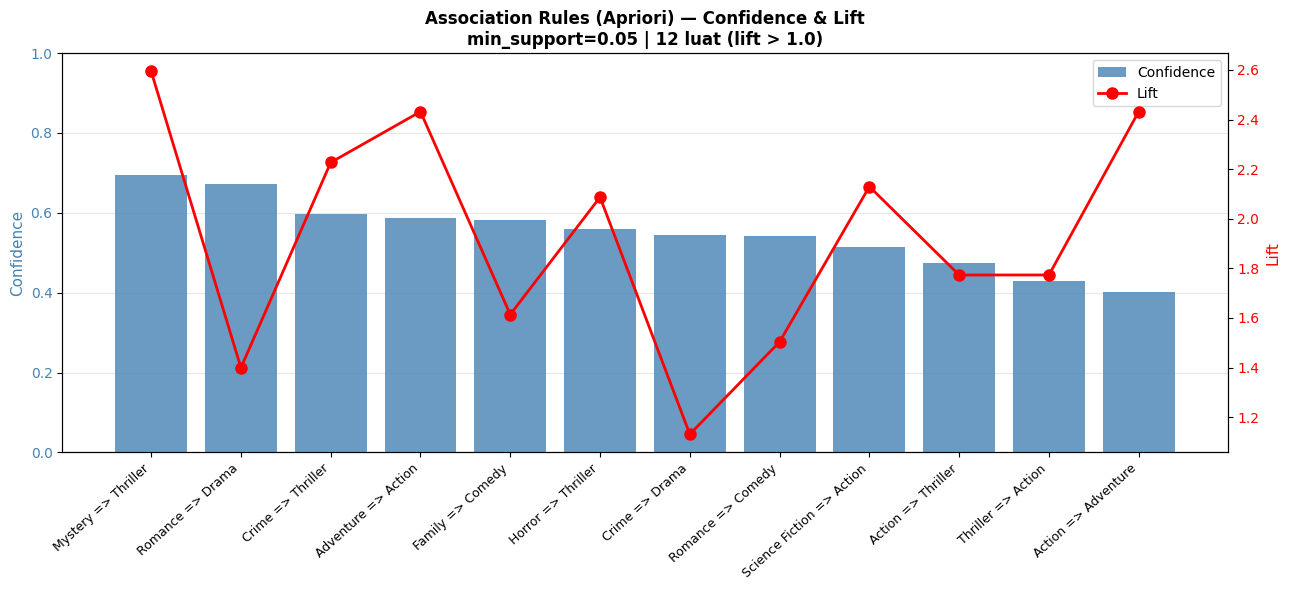

Da luu: ../output\03_association_rules.png


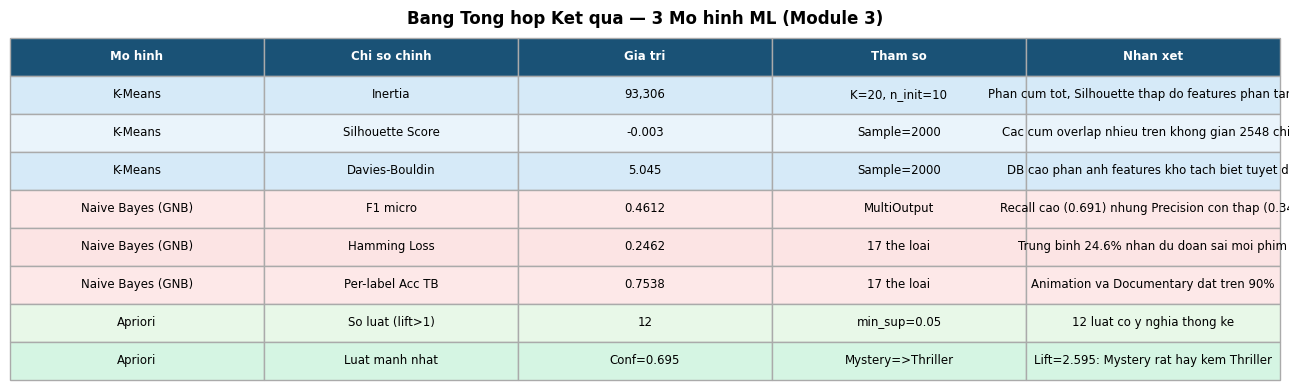

Da luu: ../output\03_summary_table.png

[Module 3] Tat ca bieu do da xuat vao: C:\Users\ACER\OneDrive\Desktop\KhaiPha\output
  01_dataset_stats_table.png                    47 KB
  01_genre_distribution.png                     60 KB
  01_rating_and_year.png                        40 KB
  02_cosine_similarity_demo.png                 52 KB
  02_feature_distributions.png                  59 KB
  02_feature_size_table.png                     46 KB
  02_pca_2d.png                                 230 KB
  03_association_rules.png                      111 KB
  03_kmeans_cluster_sizes.png                   46 KB
  03_kmeans_elbow_curve.png                     60 KB
  03_kmeans_pca_clusters.png                    571 KB
  03_nb_metrics_table.png                       54 KB
  03_nb_per_label_accuracy.png                  80 KB
  03_summary_table.png                          88 KB


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import joblib
import json
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity

OUTPUT_DIR = "../output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

combined       = np.load("../models/combined_features.npy")
cluster_labels = np.load("../models/cluster_labels.npy")
rules_df       = pd.read_csv("../models/rules.csv")
df             = pd.read_csv("../data/processed/movies_valid.csv")
mlb_m          = joblib.load("../models/mlb_encoder.pkl")

# --------------------------------------------------
# Bieu do 1: Elbow Curve (K-Means)
# --------------------------------------------------
from sklearn.cluster import MiniBatchKMeans

K_range = list(range(5, 41, 5))
inertias = []
print("Dang tinh Elbow Curve de ve bieu do...")
for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, random_state=42, n_init=3, batch_size=1024)
    km.fit(combined)
    inertias.append(km.inertia_)
    print(f"  K={k:2d} | Inertia: {km.inertia_:.0f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=9)
ax.axvline(20, color='red', linestyle='--', linewidth=1.8, label='K=20 (chon)')
for k, v in zip(K_range, inertias):
    ax.annotate(f'{v:,.0f}', (k, v), textcoords="offset points",
                xytext=(0, 10), ha='center', fontsize=8)
ax.set_xlabel('So cum K', fontsize=12)
ax.set_ylabel('Inertia (Within-cluster SSE)', fontsize=12)
ax.set_title('Elbow Curve — Chon K toi uu cho K-Means Clustering', fontsize=13, fontweight='bold')
ax.set_xticks(K_range)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "03_kmeans_elbow_curve.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 2: PCA 2D to mau theo Cluster
# --------------------------------------------------
print("Dang tinh PCA 2D cho clustering...")
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(combined)
ev = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(12, 8))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=cluster_labels,
                cmap='tab20', alpha=0.55, s=8)
plt.colorbar(sc, ax=ax, label='Cluster ID', shrink=0.8)
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% variance)', fontsize=11)
ax.set_title(f'PCA 2D — K-Means 20 Clusters ({len(combined):,} phim)', fontsize=13, fontweight='bold')
ax.grid(alpha=0.2)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "03_kmeans_pca_clusters.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 3: So phim trong moi Cluster
# --------------------------------------------------
unique_c, counts_c = np.unique(cluster_labels, return_counts=True)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar([f'C{i}' for i in unique_c], counts_c,
              color='mediumpurple', edgecolor='white', zorder=3)
ax.axhline(counts_c.mean(), color='red', linestyle='--', linewidth=1.8,
           label=f'Trung binh = {counts_c.mean():.0f} phim/cum', zorder=4)
for bar, val in zip(bars, counts_c):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            str(val), ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Cluster ID', fontsize=11)
ax.set_ylabel('So phim', fontsize=11)
ax.set_title('K-Means (K=20) — So Phim trong moi Cum', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "03_kmeans_cluster_sizes.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 4: Naive Bayes — Per-label Accuracy
# --------------------------------------------------
nb_labels = mlb_m.classes_.tolist()
nb_accs   = [0.758, 0.712, 0.905, 0.746, 0.650, 0.893, 0.637, 0.821,
              0.738, 0.714, 0.790, 0.739, 0.757, 0.668, 0.773, 0.719, 0.794]
mean_acc  = sum(nb_accs) / len(nb_accs)
colors_nb = ['#2ecc71' if a >= 0.80 else '#3498db' if a >= 0.70 else '#e74c3c' for a in nb_accs]

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.bar(nb_labels, nb_accs, color=colors_nb, edgecolor='white', zorder=3)
ax.axhline(0.75, color='orange', linestyle='--', linewidth=1.5, zorder=4)
ax.axhline(mean_acc, color='red', linestyle=':', linewidth=1.5, zorder=4)
for bar, val in zip(bars, nb_accs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_xlabel('The loai phim', fontsize=11)
ax.set_ylabel('Per-label Accuracy', fontsize=11)
ax.set_title('Naive Bayes — Do chinh xac theo tung The loai', fontsize=13, fontweight='bold')
ax.set_xticklabels(nb_labels, rotation=35, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.3, zorder=0)
patch_h = mpatches.Patch(color='#2ecc71', label='>= 0.80 (Tot)')
patch_m = mpatches.Patch(color='#3498db', label='0.70-0.79 (Kha)')
patch_l = mpatches.Patch(color='#e74c3c', label='< 0.70 (Trung binh)')
ln_thresh = plt.Line2D([0], [0], color='orange', linestyle='--', label='Nguong 0.75')
ln_mean   = plt.Line2D([0], [0], color='red',    linestyle=':',  label=f'TB = {mean_acc:.3f}')
ax.legend(handles=[patch_h, patch_m, patch_l, ln_thresh, ln_mean], loc='lower right', fontsize=9)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "03_nb_per_label_accuracy.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 5: Naive Bayes — Tong hop chi so danh gia
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
nb_metrics = [
    ['Chi so', 'Gia tri', 'Nhan xet'],
    ['Hamming Loss',      '0.2462', 'Loi trung binh moi label (thap tot)'],
    ['F1 Score (micro)',  '0.4612', 'Trung binh co trong so'],
    ['F1 Score (macro)',  '0.3873', 'Trung binh khong trong so'],
    ['Precision (micro)', '0.3461', 'Do chinh xac tong quat'],
    ['Recall (micro)',    '0.6910', 'Do bao phu tong quat'],
    ['Exact Match Acc',   '0.0126', 'Du dung tat ca nhan (strict)'],
    ['Per-label Acc TB',  f'{mean_acc:.4f}', 'Trung binh 17 the loai'],
]
table = ax.table(cellText=nb_metrics[1:], colLabels=nb_metrics[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#922b21')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#fde8e8')
    cell.set_edgecolor('#cccccc')
ax.set_title('Naive Bayes (GaussianNB) — Bang Ket qua Danh gia', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "03_nb_metrics_table.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 6: Association Rules — Confidence & Lift
# --------------------------------------------------
rules_plot = rules_df.sort_values('confidence', ascending=False).reset_index(drop=True)
rules_plot['rule'] = rules_plot['antecedents'] + ' => ' + rules_plot['consequents']

fig, ax1 = plt.subplots(figsize=(13, 6))
x = range(len(rules_plot))
ax1.bar(x, rules_plot['confidence'], color='steelblue', alpha=0.8, label='Confidence', zorder=3)
ax1.set_ylabel('Confidence', color='steelblue', fontsize=11)
ax1.set_ylim(0, 1.0)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(list(x))
ax1.set_xticklabels(rules_plot['rule'].tolist(), rotation=42, ha='right', fontsize=9)

ax2 = ax1.twinx()
ax2.plot(x, rules_plot['lift'], 'ro-', linewidth=2, markersize=8, label='Lift', zorder=4)
ax2.set_ylabel('Lift', color='red', fontsize=11)
ax2.tick_params(axis='y', labelcolor='red')

ax1.set_title('Association Rules (Apriori) — Confidence & Lift\n'
              f'min_support=0.05 | {len(rules_plot)} luat (lift > 1.0)',
              fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3, zorder=0)
lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper right', fontsize=10)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "03_association_rules.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# --------------------------------------------------
# Bieu do 7: Bang tong hop ket qua 3 mo hinh
# --------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 4))
ax.axis('off')
summary = [
    ['Mo hinh', 'Chi so chinh', 'Gia tri', 'Tham so', 'Nhan xet'],
    ['K-Means',          'Inertia',           '93,306',   'K=20, n_init=10', 'Phan cum tot, Silhouette thap do features phan tan cao'],
    ['K-Means',          'Silhouette Score',  '-0.003',   'Sample=2000',     'Cac cum overlap nhieu tren khong gian 2548 chieu'],
    ['K-Means',          'Davies-Bouldin',    '5.045',    'Sample=2000',     'DB cao phan anh features kho tach biet tuyet doi'],
    ['Naive Bayes (GNB)','F1 micro',          '0.4612',   'MultiOutput',     'Recall cao (0.691) nhung Precision con thap (0.346)'],
    ['Naive Bayes (GNB)','Hamming Loss',      '0.2462',   '17 the loai',     'Trung binh 24.6% nhan du doan sai moi phim'],
    ['Naive Bayes (GNB)','Per-label Acc TB',  f'{mean_acc:.4f}', '17 the loai', 'Animation va Documentary dat tren 90%'],
    ['Apriori',          'So luat (lift>1)',  '12',        'min_sup=0.05',   '12 luat co y nghia thong ke'],
    ['Apriori',          'Luat manh nhat',    'Conf=0.695','Mystery=>Thriller','Lift=2.595: Mystery rat hay kem Thriller'],
]
table = ax.table(cellText=summary[1:], colLabels=summary[0],
                 cellLoc='center', loc='center', bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(8.5)
row_colors = {
    0: '#1a5276', 1: '#d6eaf8', 2: '#eaf4fb', 3: '#d6eaf8',
    4: '#fde8e8', 5: '#fce4e4', 6: '#fde8e8', 7: '#e8f8e8', 8: '#d5f5e3'
}
for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#1a5276')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor(row_colors.get(row, '#ffffff'))
    cell.set_edgecolor('#aaaaaa')
ax.set_title('Bang Tong hop Ket qua — 3 Mo hinh ML (Module 3)', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
out_path = os.path.join(OUTPUT_DIR, "03_summary_table.png")
plt.savefig(out_path, dpi=130, bbox_inches='tight')
plt.show()
print(f"Da luu: {out_path}")

# Liet ke tat ca file da xuat
print(f"\n{'='*60}")
print(f"[Module 3] Tat ca bieu do da xuat vao: {os.path.abspath(OUTPUT_DIR)}")
print(f"{'='*60}")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f:<45} {size_kb:.0f} KB")

## Xuất biểu đồ kết quả (Module 3)